TÉCNICA Ensemble Random Forest (con datos preprocesados)

In [ ]:
import os
import numpy as np
import pandas as pd

root_dir = r"../Spectra/FinalSamples/Level2"
dir_wln = os.path.join(root_dir, f"LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")

In [ ]:

#Leer archivo de concentraciones
root_dir_concentraciones = r"../Spectra/FinalSamples"
dir_concentraciones = os.path.join(root_dir_concentraciones, f"concentraciones.txt")
concentraciones = pd.read_csv(dir_concentraciones, sep='\t')

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
x = np.array(all_Spectra).T # Espectros de LIBS preprocesados
ys = concentraciones["Sulfato_de_Sodio"].values
y = np.array(ys) # Concentraciones de sulfato de sodio

In [24]:
# División de los datos en entrenamiento y prueba

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=28)

In [25]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42)
rf_model.fit(x_train, y_train)

# Predicciones
y_pred = rf_model.predict(x_test)

# Evaluación
mse = mean_squared_error(y_test, y_pred)
print(f"MSE con Random Forest: {mse}")


MSE con Random Forest: 34.73511045303728


In [16]:
y_pred = rf_model.predict(x_test)
y_pred_train = rf_model.predict(x_train)

34.73511045303728
[79.79 20.95 38.76  0.   79.79 83.55  7.36 44.21 86.96 49.33 96.92 20.95
 20.95 63.51 96.92]
[74.0457     11.52986667 47.8217      5.51026667 73.53256667 78.22376667
  9.3651     43.95286667 85.3377     51.66566667 93.20273333 11.856
 27.4329     69.20296667 90.9068    ]


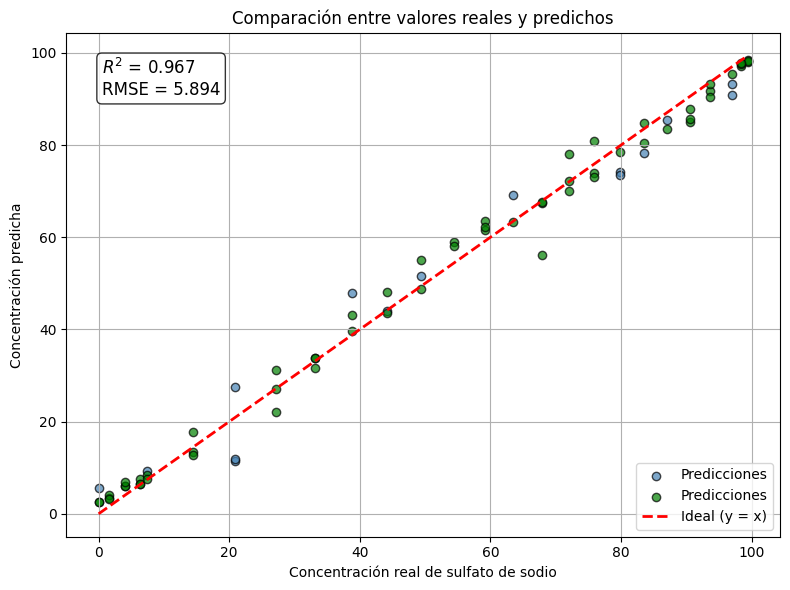

In [17]:
mse = mean_squared_error(y_test, y_pred)
print(mse)
print(y_test)
print(y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train, y_pred_train, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de sodio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Definir el modelo base
rf = RandomForestRegressor(random_state=42)

# Definir la rejilla de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar el GridSearch con validación cruzada de 5 folds
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Ajustar al conjunto de entrenamiento
grid_search.fit(x_train, y_train)

# Mejor modelo y parámetros
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor RMSE (negativo):", -grid_search.best_score_)



Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor RMSE (negativo): 7.884122315935355


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None] + list(range(5, 30, 5)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor RMSE (negativo):", -random_search.best_score_)


Mejores parámetros: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 413}
Mejor RMSE (negativo): 7.885262580462866


In [19]:
ys2 = concentraciones["Sulfato_de_Magnesio"].values
y2 = np.array(ys2) # Concentraciones de sulfato de sodio
x_train2, x_test2, y_train2, y_test2 = train_test_split(x,y2, test_size = 0.2, random_state=16)
model2 = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=69)

model2.fit(x_train2, y_train2)
y_pred2 = model2.predict(x_test2)
y_pred_train2 = model2.predict(x_train2)

51.823042080666646
[ 61.24 100.    98.34  36.49  20.21  24.12  27.99  13.04   0.63  20.21
   9.5   96.02  79.05  16.45  72.84]
[49.0002     92.8604     93.77786667 31.25123333 19.9158     14.35666667
 12.54766667 19.34193333  3.29193333 20.0195     14.2353     90.08433333
 85.95023333 22.69156667 71.0058    ]


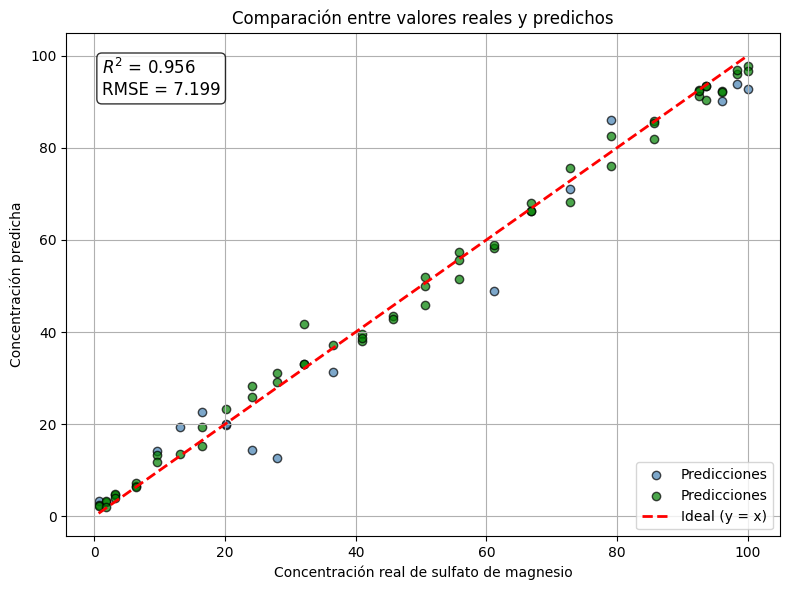

In [20]:
mse = mean_squared_error(y_test2, y_pred2)
print(mse)
print(y_test2)
print(y_pred2)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test2, y_pred2, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train2, y_pred_train2, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train2), max(y_train2)], [min(y_train2), max(y_train2)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de magnesio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Técnica Ensemble Random Forest (con datos sin preprocesar)

In [26]:
# Ruta donde están los archivos LVL2_MX_PY.txt
root_dir = r"../Spectra/FinalSamples/Level1"

# Se guardarán aquí:
wavelengths = None            # array 1D con las longitudes de onda del primer archivo válido
intensity_cols = []           # lista de arrays 1D con las intensidades de cada archivo
filenames = []                # lista de nombres de archivos cargados, en orden

# Recorremos MX=1..27 y PY=1..3 en orden numérico
for mx in range(1, 28):
    for py in range(1, 4):
        fname = f"LVL1_M{mx}_P{py}.txt"
        fpath = os.path.join(root_dir, fname)
        try:
            # Cargar dos columnas: wave, intensity
            data = np.loadtxt(fpath, delimiter=',')
            wave = data[:, 0]
            spec = data[:, 1]
            
            # Si es el primer archivo válido, guardamos las longitudes
            if wavelengths is None:
                wavelengths = wave.copy()
            else:
                # Chequeo rápido: que coincidan los ejes
                if not np.allclose(wavelengths, wave):
                    raise ValueError(f"El eje de longitudes no coincide en {fname}")
            
            # Añadimos la columna de intensidades y el nombre
            intensity_cols.append(spec)
            filenames.append(fname)
        except Exception:
            # No existe el archivo o hay error: lo ignoramos
            continue
# Ahora componemos la matriz (N, k)
if intensity_cols:
    intensity_matrix = np.column_stack(intensity_cols)  # shape (N, k)
else:
    intensity_matrix = np.empty((0, 0))


# Mostramos resultados
# intensity_matrix: shape (N, k)
# filenames: list of length k, e.g. ['LVL1_1_1.txt', 'LVL1_1_2.txt', …]
print("Archivos cargados en orden:")
print(filenames)
print(f"\nLongitudes de onda (N={wavelengths.size if wavelengths is not None else 0}):")
print(wavelengths)
print(f"\nMatriz de intensidades (shape={intensity_matrix.shape}):")
print(intensity_matrix)


out_wln = os.path.join(root_dir, f"LVL1_Wavelengths.txt")
out_spec = os.path.join(root_dir, f"LVL1_All_Spectra.txt")

# Write a header line with the original file‑names, tab‑delimited
header = "\t".join(filenames)


# Save the Spectra matrix
np.savetxt(out_spec,intensity_matrix,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    header=header,
    comments=""         # don’t prefix the header with “#”
)

# Save the Wavelengths matrix
np.savetxt(out_wln,wavelengths,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    comments=""         # don’t prefix the header with “#”
)

Archivos cargados en orden:
['LVL1_M1_P1.txt', 'LVL1_M1_P2.txt', 'LVL1_M1_P3.txt', 'LVL1_M2_P1.txt', 'LVL1_M2_P2.txt', 'LVL1_M2_P3.txt', 'LVL1_M3_P1.txt', 'LVL1_M3_P2.txt', 'LVL1_M3_P3.txt', 'LVL1_M4_P1.txt', 'LVL1_M4_P2.txt', 'LVL1_M4_P3.txt', 'LVL1_M5_P1.txt', 'LVL1_M5_P2.txt', 'LVL1_M5_P3.txt', 'LVL1_M6_P1.txt', 'LVL1_M6_P2.txt', 'LVL1_M6_P3.txt', 'LVL1_M7_P1.txt', 'LVL1_M7_P2.txt', 'LVL1_M7_P3.txt', 'LVL1_M8_P1.txt', 'LVL1_M8_P2.txt', 'LVL1_M8_P3.txt', 'LVL1_M9_P1.txt', 'LVL1_M9_P2.txt', 'LVL1_M9_P3.txt', 'LVL1_M10_P1.txt', 'LVL1_M10_P2.txt', 'LVL1_M10_P3.txt', 'LVL1_M11_P1.txt', 'LVL1_M11_P2.txt', 'LVL1_M11_P3.txt', 'LVL1_M12_P1.txt', 'LVL1_M12_P2.txt', 'LVL1_M12_P3.txt', 'LVL1_M13_P2.txt', 'LVL1_M13_P3.txt', 'LVL1_M14_P1.txt', 'LVL1_M14_P2.txt', 'LVL1_M14_P3.txt', 'LVL1_M15_P2.txt', 'LVL1_M15_P3.txt', 'LVL1_M16_P1.txt', 'LVL1_M16_P2.txt', 'LVL1_M16_P3.txt', 'LVL1_M17_P1.txt', 'LVL1_M17_P2.txt', 'LVL1_M17_P3.txt', 'LVL1_M18_P1.txt', 'LVL1_M18_P2.txt', 'LVL1_M18_P3.txt', 'LVL1_M19_

In [27]:
root_dir = r"../Spectra/FinalSamples/Level1"
dir_wln = os.path.join(root_dir, f"LVL1_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"LVL1_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra_non_processed = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")

In [28]:
x3 = np.array(all_Spectra_non_processed).T # Espectros de LIBS preprocesados
ys3 = concentraciones["Sulfato_de_Sodio"].values
y3 = np.array(ys3) # Concentraciones de sulfato de sodio

In [29]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(x3,y3, test_size = 0.2, random_state=17)
model3 = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=71)
model3.fit(x_train3, y_train3)

y_pred3 = model3.predict(x_test3)
y_pred_train3 = model3.predict(x_train3)

191.41338494681455
[49.33 90.5  20.95 75.88 14.4  98.31 96.92 96.92 38.76  7.36 38.76  6.29
  6.29 93.63 33.15]
[38.05123333 80.32666667 30.5522     74.05636667 18.1702     88.8397
 93.98706667 92.0591     56.9781     21.61853333 61.0075      6.76333333
  3.91586667 57.53613333 41.5196    ]


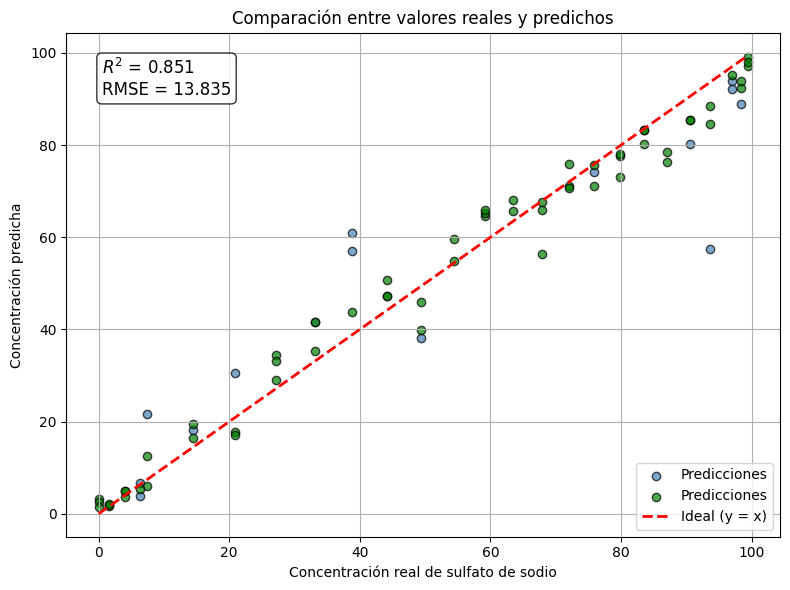

In [30]:
mse = mean_squared_error(y_test3, y_pred3)
print(mse)
print(y_test3)
print(y_pred3)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test3, y_pred3)

plt.figure(figsize=(8, 6))
plt.scatter(y_test3, y_pred3, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train3, y_pred_train3, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train3), max(y_train3)], [min(y_train3), max(y_train3)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de sodio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

181.2615180962969
[50.67  9.5  79.05 24.12 85.6   1.69  3.08  3.08 61.24 92.64 61.24 93.71
 93.71  6.37 66.85]
[60.91603333 18.7997     68.79856667 25.82323333 81.2508     10.95366667
  6.09376667  7.477      43.99823333 78.17583333 39.9508     92.62286667
 96.61106667 41.5776     58.05096667]


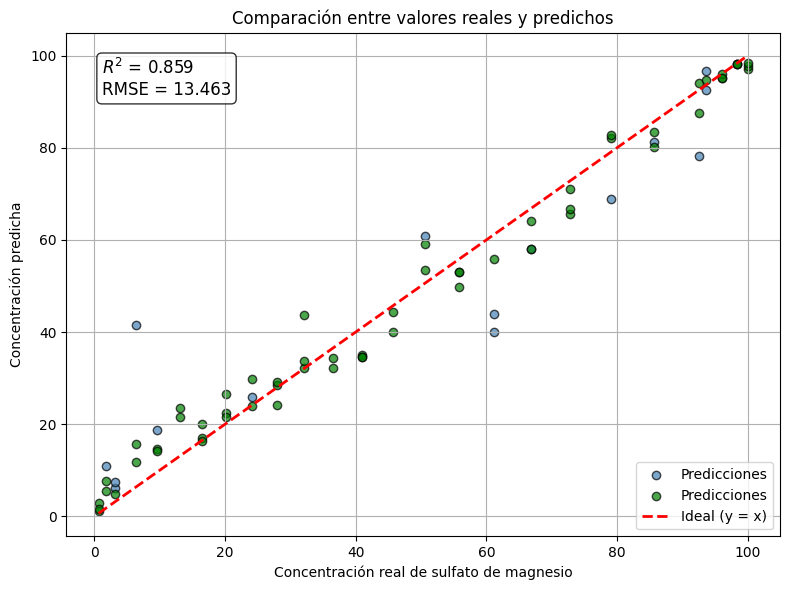

In [31]:
ys4 = concentraciones["Sulfato_de_Magnesio"].values
y4 = np.array(ys4)

x_train4, x_test4, y_train4, y_test4 = train_test_split( x3 ,y4, test_size = 0.2, random_state=17)
model4 = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=71)
model4.fit(x_train4, y_train4)

y_pred4 = model4.predict(x_test4)
y_pred_train4 = model4.predict(x_train4)

mse = mean_squared_error(y_test4, y_pred4)
print(mse)
print(y_test4)
print(y_pred4)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test4, y_pred4)

plt.figure(figsize=(8, 6))
plt.scatter(y_test4, y_pred4, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train4, y_pred_train4, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train4), max(y_train4)], [min(y_train4), max(y_train4)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de magnesio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')


# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()